## 1. Core Concepts of Machine Learning

*   **Supervised Learning:** Learning from labeled data. We have input features (X) and a known output target (y). The goal is to learn a mapping function `y = f(X)`.
    *   **Regression:** Predicting a continuous value (e.g., price, temperature, salary).
    *   **Classification:** Predicting a discrete category (e.g., Spam/Not Spam, Cat/Dog).
*   **Unsupervised Learning:** Learning from unlabeled data. The goal is to find hidden patterns or structures in the data (e.g., clustering customers into groups).

    
*   **Reinforcement Learning:** Learning by interacting with an environment. An agent learns to take actions that maximize a reward over time.
    * The agent gets feedback in the form of rewards or penalties.
    * Common in robotics, games (e.g., AlphaGo), and self-driving cars.




*   **The ML Workflow:**
    1.  Get Data
    2.  Explore & Preprocess Data (EDA)
    3.  Split Data (Train/Test)
    4.  Choose & Train a Model
    5.  Evaluate the Model


## 2. Linear Regression

Linear Regression is the "hello world" of supervised learning. It assumes a linear relationship between the input features (X) 
and the output target (y).

**Formula:** `y = w_1*x_1 + w_2*x_2 + ... + w_n*x_n + b`

*   `y`: The predicted value.
*   `x_i`: The input features.
*   `w_i`: The weights or coefficients (what the model learns). Represents the importance of each feature.
*   `b`: The bias or intercept.


In [ ]:
MSE (Mean Squared Error) is used for regression, where the goal is to 
predict a continuous number (like house price or temperature)

In [ ]:
## 3. Hands-On: Salary Prediction

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the Data
data = {
    'YearsExperience': [1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7, 3.9, 4.0, 4.0, 4.1, 4.5, 4.9, 5.1, 5.3, 5.9, 6.0, 6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5],
    'Salary': [39343, 46205, 37731, 43525, 39891, 56642, 60150, 54445, 64445, 57189, 63218, 55794, 56957, 57081, 61111, 67938, 66029, 83088, 81363, 93940, 91738, 98273, 101302, 113812, 109431, 105582, 116969, 112635, 122391, 121872]
}
df = pd.DataFrame(data)

# 2. Exploratory Data Analysis (EDA)

print(df.head())

df.info()

   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


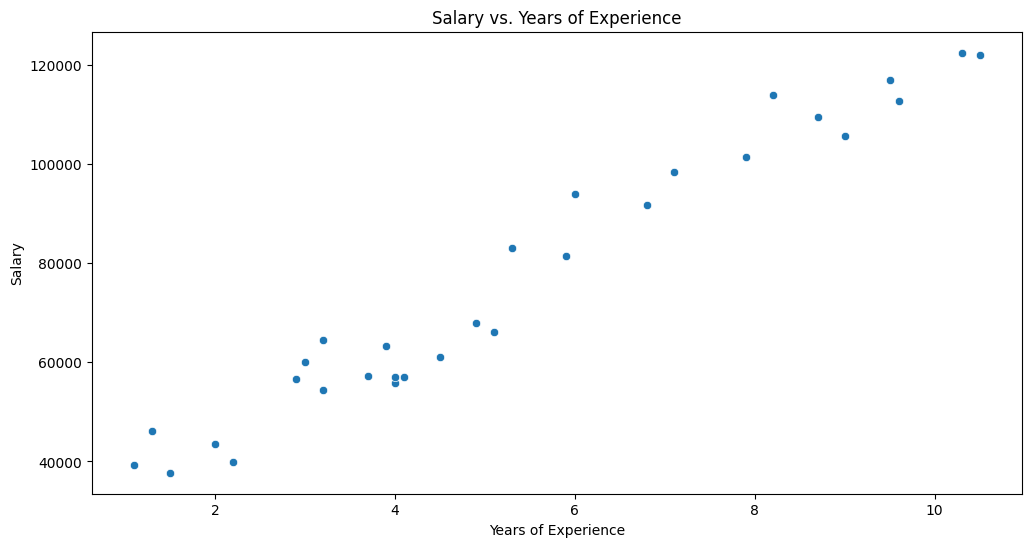

In [2]:
# Visualize the relationship
plt.figure(figsize=(12, 6))
sns.scatterplot(x='YearsExperience', y='Salary', data=df)
plt.title('Salary vs. Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

In [3]:
# 3. Prepare Data for Modeling
# X should be a 2D array, so we use [['YearsExperience']]
X = df[['YearsExperience']]
print(X.shape)
y = df['Salary']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

(30, 1)

Training set shape: (24, 1)
Testing set shape: (6, 1)


In [4]:
X_test


,YearsExperience
27,9.6
15,4.9
23,8.2
17,5.3
8,3.2
9,3.7


In [5]:
y_test

27    112635
15     67938
23    113812
17     83088
8      64445
9      57189
Name: Salary, dtype: int64

In [7]:
# 4. Choose & Train the Model
model = LinearRegression()
model.fit(X_train, y_train)
print("\nModel training complete.")

# Print the learned parameters
print(f"Coefficient (w1): {model.coef_[0]}")
print(f"Intercept (b): {model.intercept_}")


Model training complete.
Coefficient (w1): 9423.815323030976
Intercept (b): 25321.583011776813


## Mean Squared Error (MSE)

$$
MSE = \frac{1}{n} \sum (y_{actual} - y_{predicted})^2
$$


In [ ]:
Actual (y)	Predicted (ŷ)
3	          2
5	          4
7	          8

Step 1: Calculate errors
3 - 2 = 1
5 - 4 = 1
7 - 8 = -1

Step 2: Square them
1² = 1
1² = 1
(-1)² = 1

Step 3: Average
MSE = (1 + 1 + 1) / 3 = 1


👉 MSE = 1

## R-squared (R²) Formula

$$
R^2 = 1 - \frac{SS_{residual}}{SS_{total}}
$$

### Where:

$$
SS_{residual} = \sum (y_{actual} - y_{predicted})^2
$$

$$
SS_{total} = \sum (y_{actual} - \bar{y})^2
$$

$$
\bar{y} = \text{mean of actual values}
$$


In [8]:
X_test

,YearsExperience
27,9.6
15,4.9
23,8.2
17,5.3
8,3.2
9,3.7


In [9]:
y_test

27    112635
15     67938
23    113812
17     83088
8      64445
9      57189
Name: Salary, dtype: int64

In [10]:
# 5. Evaluate the Model
y_pred = model.predict(X_test)

In [11]:
# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}") # R2 is the proportion, Closer to 1 is better.

Mean Squared Error (MSE): 49830096.86
Root Mean Squared Error (RMSE): 7059.04
R-squared (R2): 0.90


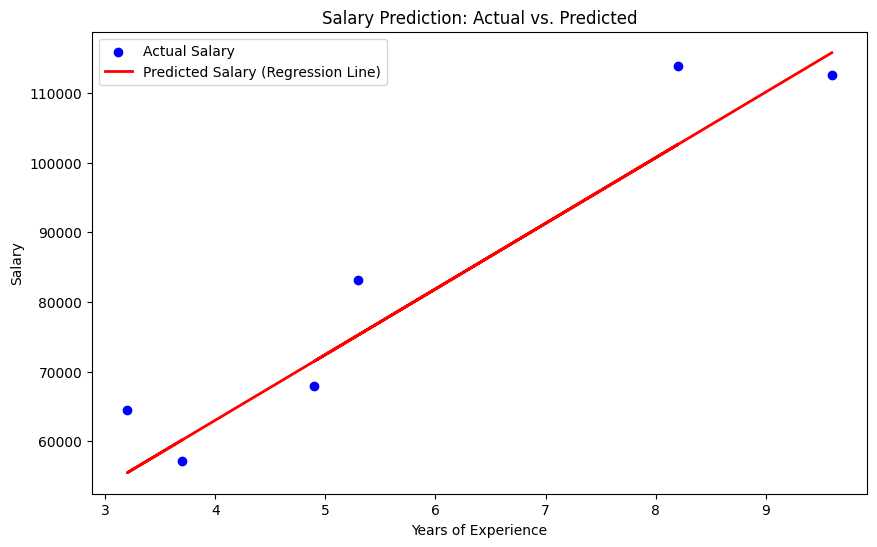

In [12]:
# 6. Visualize the Results
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Salary')

plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted Salary (Regression Line)')
plt.title('Salary Prediction: Actual vs. Predicted')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

In [13]:
# 7. Make a new prediction
new_experience = np.array([[5]]) 
predicted_salary = model.predict(new_experience)
print(f"\nPredicted salary for {new_experience[0][0]} years of experience: NPR{predicted_salary[0]:.2f}")


Predicted salary for 5 years of experience: NPR72440.66


C:\Users\HP ProBook\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [14]:
np.random.seed(42)

years = np.linspace(0.5, 20, 100)
salary = 30000 + (years * 9000) + np.random.normal(0, 8000, 100)

df_generated = pd.DataFrame({
    'YearsExperience': years,
    'Salary': salary.astype(int)
})

print(df_generated.head())


   YearsExperience  Salary
0         0.500000   38473
1         0.696970   35166
2         0.893939   43226
3         1.090909   52002
4         1.287879   39717


In [15]:
# Additional data points
more_data = {
    'YearsExperience': [
        0.5, 0.8, 1.0,
        11.0, 11.5, 12.0, 12.5,
        13.0, 13.5, 14.0,
        15.0, 16.0, 17.0, 18.0, 19.0, 20.0
    ],
    'Salary': [
        32000, 35000, 38000,
        125000, 130000, 135000, 138000,
        142000, 148000, 150000,
        160000, 170000, 180000, 190000, 200000, 210000
    ]
}

df_more = pd.DataFrame(more_data)

# Combine with original dataset
df_extended = pd.concat([df, df_more, df_generated], ignore_index=True)

print(df_extended.tail())
print("Total records:", len(df_extended))


     YearsExperience  Salary
141        19.212121  191200
142        19.409091  207050
143        19.606061  208542
144        19.803030  208268
145        20.000000  208123
Total records: 146


In [16]:
# 3. Prepare Data for Modeling
# X should be a 2D array, so we use [['YearsExperience']]
X = df_extended[['YearsExperience']]
print(X.shape)
y = df_extended['Salary']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

(146, 1)

Training set shape: (116, 1)
Testing set shape: (30, 1)


In [17]:
# 4. Choose & Train the Model
model = LinearRegression()
model.fit(X_train, y_train)
print("\nModel training complete.")

# Print the learned parameters
print(f"Coefficient (w1): {model.coef_[0]}")
print(f"Intercept (b): {model.intercept_}")


Model training complete.
Coefficient (w1): 9089.371227091564
Intercept (b): 27966.141155657242


In [18]:
len(X_test)

30

In [19]:
# 5. Evaluate the Model
y_pred = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}") # R2 is the proportion, Closer to 1 is better.

Mean Squared Error (MSE): 53100684.19
Root Mean Squared Error (RMSE): 7287.02
R-squared (R2): 0.98


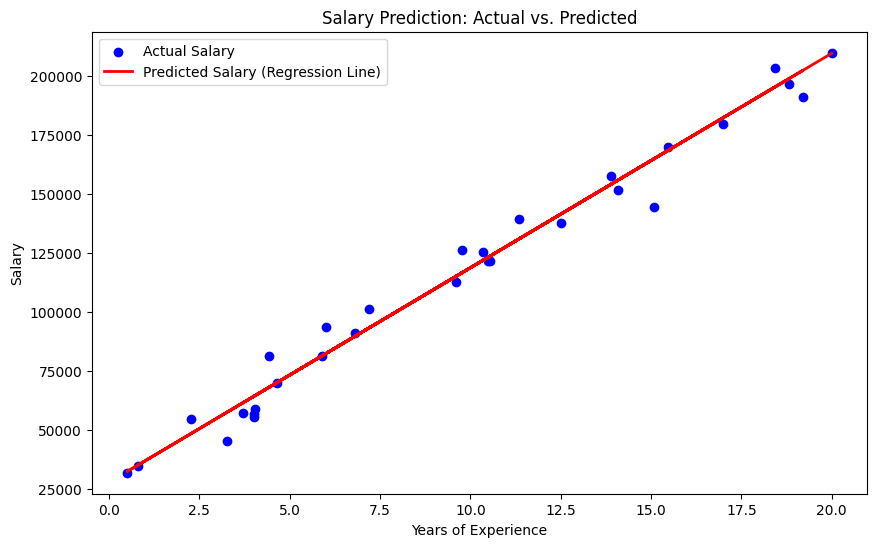

In [20]:
# 6. Visualize the Results
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Salary')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted Salary (Regression Line)')
plt.title('Salary Prediction: Actual vs. Predicted')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

In [21]:
# 7. Make a new prediction
new_experience = np.array([[5]]) 
predicted_salary = model.predict(new_experience)
print(predicted_salary)
print(f"\nPredicted salary for {new_experience[0][0]} years of experience: ${predicted_salary[0]:.2f}")

[73412.99729112]

Predicted salary for 5 years of experience: $73413.00


C:\Users\HP ProBook\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [22]:
new_data = pd.DataFrame({'YearsExperience': [5]})

In [23]:
predicted_salary = model.predict(new_data)
print(predicted_salary)
print(f"\nPredicted salary for {new_experience[0][0]} years of experience: ${predicted_salary[0]:.2f}")

[73412.99729112]

Predicted salary for 5 years of experience: $73413.00


In [24]:
import joblib
joblib.dump(model, 'salary_linear_regression.pkl')

['salary_linear_regression.pkl']

In [25]:
model_file = 'salary_linear_regression.pkl'
model = joblib.load(model_file)


model.predict([[5]])


C:\Users\HP ProBook\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([73412.99729112])



### Model Equation

$$
y = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b
$$

Where:

- $y$ : The predicted value  
- $x_i$ : The input features  
- $w_i$ : The weights (coefficients learned by the model)  
- $b$ : The bias (intercept)

---




## Multiple Linear Regression Example

In this example, we predict **House Price** using multiple features:

- $x_1$ = Size of the house (in square feet)  
- $x_2$ = Number of bedrooms  
- $x_3$ = Age of the house (in years)  

Target:
- $y$ = House price

---

### Model Equation

$$
y = w_1 x_1 + w_2 x_2 + w_3 x_3 + b
$$

Where:

- $y$ : Predicted house price  
- $x_1, x_2, x_3$ : Input features  
- $w_1, w_2, w_3$ : Learned weights (importance of each feature)  
- $b$ : Bias (intercept)

---

### Example With Actual Numbers

Assume the model learned:

$$
w_1 = 120, \quad w_2 = 15000, \quad w_3 = -3000, \quad b = 50000
$$

For a house with:

- Size = 2000 sq ft  
- Bedrooms = 3  
- Age = 10 years  

Prediction:

$$
y = (120 \times 2000) + (15000 \times 3) + (-3000 \times 10) + 50000
$$

$$
y = 240000 + 45000 - 30000 + 50000
$$

$$
y = 305000
$$

So, the predicted house price is:

$$
y = 305000
$$

---

### Vector Form (Compact Representation)

Multiple Linear Regression can also be written as:

$$
y = \mathbf{w}^T \mathbf{x} + b
$$

Where:

$$
\mathbf{w} =
\begin{bmatrix}
w_1 \\
w_2 \\
w_3
\end{bmatrix}
\quad
\mathbf{x} =
\begin{bmatrix}
x_1 \\
x_2 \\
x_3
\end{bmatrix}
$$


In [26]:
# Multiple features dataset
# X1 = Size (sq ft)
# X2 = Bedrooms
# X3 = Age (years)
# y  = House price

X_multi = np.array([
    [2000, 3, 5],
    [1500, 2, 10],
    [2500, 4, 3],
    [1800, 3, 8],
    [2200, 3, 4]
])

y_multi = np.array([300000, 200000, 400000, 280000, 350000])

# Create model
model_multi = LinearRegression()

# Train model
model_multi.fit(X_multi, y_multi)

# Print learned parameters
print("Weights (w1, w2, w3):", model_multi.coef_)
print("Bias (b):", model_multi.intercept_)

# Predict new house price
new_house = [[2100, 3, 6]]
prediction_multi = model_multi.predict(new_house)

print("Prediction for [2100 sq ft, 3 bedrooms, 6 years]:", prediction_multi[0])


Weights (w1, w2, w3): [ 1.75000000e+02  1.25000000e+04 -7.27595761e-12]
Bias (b): -81499.99999999953
Prediction for [2100 sq ft, 3 bedrooms, 6 years]: 323500.0


In [ ]:
https://www.kaggle.com/datasets/harlfoxem/housesalesprediction?select=kc_house_data.csv


In [29]:
!pip install kagglehub


   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   -------------------------- ------------- 


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harlfoxem/housesalesprediction")

print("Path to dataset files:", path)

C:\Users\HP ProBook\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 780k/780k [00:01<00:00, 584kB/s]

Extracting files...
Path to dataset files: C:\Users\HP ProBook\.cache\kagglehub\datasets\harlfoxem\housesalesprediction\versions\1


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [32]:
df =pd.read_csv(path + "/kc_house_data.csv")

In [33]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='str')

In [34]:
df.columns = [col.capitalize() for col in df.columns]

In [35]:
df.columns

Index(['Id', 'Date', 'Price', 'Bedrooms', 'Bathrooms', 'Sqft_living',
       'Sqft_lot', 'Floors', 'Waterfront', 'View', 'Condition', 'Grade',
       'Sqft_above', 'Sqft_basement', 'Yr_built', 'Yr_renovated', 'Zipcode',
       'Lat', 'Long', 'Sqft_living15', 'Sqft_lot15'],
      dtype='str')

In [37]:
df.head()

,Id,Date,Price,Bedrooms,Bathrooms,Sqft_living,Sqft_lot,Floors,Waterfront,View,...,Grade,Sqft_above,Sqft_basement,Yr_built,Yr_renovated,Zipcode,Lat,Long,Sqft_living15,Sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [36]:
df.corr(numeric_only=True)

,Id,Price,Bedrooms,Bathrooms,Sqft_living,Sqft_lot,Floors,Waterfront,View,Condition,Grade,Sqft_above,Sqft_basement,Yr_built,Yr_renovated,Zipcode,Lat,Long,Sqft_living15,Sqft_lot15
Id,1.000000,-0.016762,0.001286,0.005160,-0.012258,-0.132109,0.018525,-0.002721,0.011592,-0.023783,0.008130,-0.010842,-0.005151,0.021380,-0.016907,-0.008224,-0.001891,0.020799,-0.002901,-0.138798
Price,-0.016762,1.000000,0.308350,0.525138,0.702035,0.089661,0.256794,0.266369,0.397293,0.036362,0.667434,0.605567,0.323816,0.054012,0.126434,-0.053203,0.307003,0.021626,0.585379,0.082447
Bedrooms,0.001286,0.308350,1.000000,0.515884,0.576671,0.031703,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477600,0.303093,0.154178,0.018841,-0.152668,-0.008931,0.129473,0.391638,0.029244
Bathrooms,0.005160,0.525138,0.515884,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685342,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175
Sqft_living,-0.012258,0.702035,0.576671,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876597,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286
Sqft_lot,-0.132109,0.089661,0.031703,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183512,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557
Floors,0.018525,0.256794,0.175429,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
Waterfront,-0.002721,0.266369,-0.006582,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
View,0.011592,0.397293,0.079532,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575
Condition,-0.023783,0.036362,0.028472,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158214,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406


In [41]:
# 2. FEATURE ENGINEERING
df['Age_years'] = 2015 - df['Yr_built']



In [42]:
features = ['Sqft_living', 'Bedrooms', 'Age_years']

In [43]:
X = df[features]
y = df['Price']

# 4. SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. TRAIN MODEL
model = LinearRegression()
model.fit(X_train, y_train)

# 6. INTERPRET RESULTS
print("\n--- Learned Parameters ---")
print(f"Weight (Sqft_lot): {model.coef_[0]:.2f}")
print(f"Weight (Bedrooms):    {model.coef_[1]:.2f}")
print(f"Weight (Age_years):   {model.coef_[2]:.2f}")
print(f"Bias (Intercept):     {model.intercept_:.2f}")


# 7. EVALUATION
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nModel Accuracy (R^2 Score): {r2:.4f}")

# 8. PREDICTION
# Predict price for: 2100 sq ft, 3 bedrooms, 6 years old
# Note: We must use the exact same column names as X
new_house = pd.DataFrame([[2100, 3, 6]], columns=features)
prediction = model.predict(new_house)


--- Learned Parameters ---
Weight (Sqft_lot): 339.18
Weight (Bedrooms):    -58979.21
Weight (Age_years):   2421.43
Bias (Intercept):     -73294.46

Model Accuracy (R^2 Score): 0.5381


In [44]:
prediction

array([476582.41040113])

In [45]:
print(f"Predicted House Price: ${prediction[0]:,.2f}")

Predicted House Price: $476,582.41
